In [1]:
import os
import sys
import datetime as dt
import cmocean as cmo

import cartopy.crs as ccrs
import easygems.healpix as egh
import intake
import matplotlib.pyplot as plt
import numpy as np

import healpy as hp
import xarray as xr

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
# Filter out annoying warning.
import warnings

from utils import haversine, hp_mods, get_nn_lon_lat_index

warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

ERROR 1: PROJ: proj_create_from_database: Open of /home/users/franmorr/.conda/envs/hk26_env/share/proj failed


In [2]:
# Open catalog.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
# sim = 'um_glm_n2560_RAL3p3_tuned_hk26'
sim = 'um_glm_n1280_GAL9_v2_hk26'
sim_cat = cat[sim]
ds = sim_cat(zoom=3, time='PT1H').to_dask().pipe(hp_mods)

In [3]:
[sim for sim in cat]

['CERES_EBAF',
 'ERA5',
 'IR_IMERG',
 'JRA3Q',
 'MERRA2',
 'arp-gem-1p3km',
 'arp-gem-2p6km',
 'casesm2_10km_nocumulus',
 'icon_d3hp003',
 'icon_d3hp003aug',
 'icon_d3hp003feb',
 'icon_ngc4008',
 'ifs_tco3999-ng5_deepoff',
 'ifs_tco3999-ng5_rcbmf',
 'ifs_tco3999-ng5_rcbmf_cf',
 'ifs_tco3999_rcbmf',
 'nicam_220m_test',
 'nicam_gl11',
 'scream-dkrz',
 'tracking-d3hp003',
 'um_Africa_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_Africa_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_Africa_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_CTC_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_CTC_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_CTC_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_SAmer_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SAmer_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_SEA_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26',
 'um_SEA_km4p4_RAL3P3_n1280_GAL9_nest',
 'um_SEA_km4p4_RAL3P3_n2560_CoMA9_nest_hk26',
 'um_glm_n1280_CoMA9_TBv1p2',
 'um_glm_n1280_CoMA9_hk26',

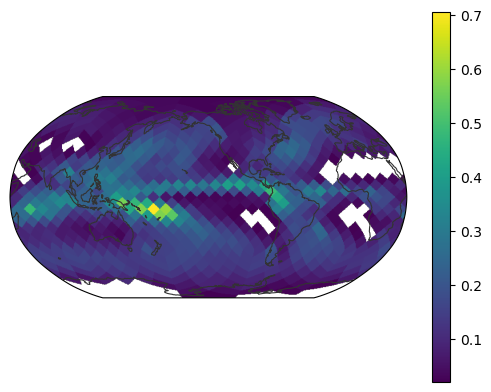

In [16]:
pr=ds.pr.mean(dim="time")*3600
pr.units=="mm h-1"
im=egh.healpix_show(pr.where(pr>0.02))
plt.colorbar(im)

## Onset Period analysis

Marcia's technique takes the following steps:
1. Butterworth filter precipitation timeseries with a 60-day window Pr_{60}
2. Take time derivative of Pr_{60}
3. Identify periods where Pr_{60} and dPr_{60}/dt are positive for 30 days or more.
4. Optionally, take each standard season and apply the RefineOns method to check it looks sensible.

Here we also calculate seasonality to check whether this is a meaningfully seasonal cycle as in [Kahana et al. (2024)](https://www.frontiersin.org/journals/climate/articles/10.3389/fclim.2024.1419704/full).

In [3]:
import OnsetPeriod_toolbox as optb
from onset_utils import onset_period, onset_period_1d, seasonality_index

# def onset_period(
#     pp,
#     deltat=None,
#     max_dry_frac_rainfall=0.3,
#     refine=False,
#     precip_threshold=None,
#     intensity_threshold=None,
# ):
#     if deltat == None:
#         deltat = pp.time.dt.dayofyear[0].item()
#     # step 1
#     flt = optb.butterworth(pp, fwin)

#     # step 2
#     grd = np.gradient(flt)

#     # step 3
#     rny = xr.where(((flt > 0) & (grd > 0)), 1, 0)
#     fd, lns = optb.FindOnsetPeriods(rny, minlen)

#     #### NOT SURE WHETHER TO REMOVE P1
#     # remove first onset period if it starts at the very beginning of the sim
#     if fd and fd[0] == 0:
#         fd = fd[1:]
#         lns = lns[1:]

#     if refine:
#         for ons_ix in range(len(fd)):
#             this_pp = pp[fd[ons_ix] : fd[ons_ix] + lns[ons_ix]]
#             fd[ons_ix], lns[ons_ix] = optb.RefineOns(
#                 pp, pp.mean(dim="time") * max_dry_frac_rainfall
#             )

#     if precip_threshold:
#         if pp.mean(dim="time") < precip_threshold:
#             return np.array([np.nan]), np.array([np.nan])

#     elif intensity_threshold:
#         ons_ix=0
#         while ons_ix in range(len(fd)):
#             this_grd_mean = (grd[fd[ons_ix] : fd[ons_ix] + lns[ons_ix]]).mean()
#             if this_grd_mean < intensity_threshold:
#                 fd.remove(fd[ons_ix])
#                 lns.remove(lns[ons_ix])
#             else:
#                 ons_ix+=1

#     # shift back to day of year rather than day of simulation
#     first_days = np.array(fd) + deltat
#     last_days = np.array(fd) + np.array(lns) + deltat

#     return first_days, last_days

# def onset_period_1d(
#     pp_1d,
#     time,
#     max_periods=5,
#     max_dry_frac_rainfall=0.3,
#     refine=False,
#     precip_threshold=None,
#     intensity_threshold=None,
# ):
#     """
#     Apply onset_period to one grid-cell time series.

#     Returns fixed-length arrays so xarray can combine outputs.
#     """
#     pp = xr.DataArray(
#         pp_1d,
#         dims=["time"],
#         coords={"time": time},
#     )

#     deltat = int(pp.time.dt.dayofyear[0].item())

#     first_days, last_days = onset_period(
#         pp,
#         deltat=deltat,
#         max_dry_frac_rainfall=max_dry_frac_rainfall,
#         refine=refine,
#         precip_threshold=precip_threshold,
#         intensity_threshold=intensity_threshold,
#     )

#     first_out = np.full(max_periods, np.nan)
#     last_out = np.full(max_periods, np.nan)

#     n = min(len(first_days), max_periods)
#     first_out[:n] = first_days[:n]
#     last_out[:n] = last_days[:n]

#     return first_out, last_out

# def seasonality_index(pp):
#     rbar = pp.sel(time=slice("2020-03", "2021-02")).mean(dim="time")
#     x_m = pp.sel(time=slice("2020-03", "2021-02")).resample(time="1ME").mean()
#     si = (1 / rbar) * (abs((x_m - (rbar)))).mean(dim="time")
#     return si

Text(0.5, 1.0, 'Mean rainfall > 1e-05')

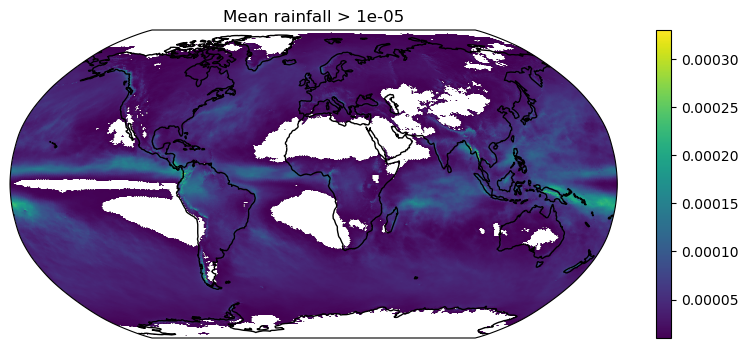

In [6]:

fwin = 60  # size of the butterworth filtering window
minlen = 30  # minimum length of the onset period envelope
si_thrs = 0
pp = ds.pr
fig, ax = plt.subplots(figsize=(10, 4), subplot_kw={"projection": ccrs.Robinson()})
ax.set_global()
ax.coastlines()
pp_plot = pp.sel(time=slice("2020-03", "2021-02")).mean(dim="time")
pr_thrs=1e-5
im = egh.healpix_show(pp_plot.where(pp_plot>pr_thrs,drop=False), ax=ax)
plt.colorbar(im)
plt.title(f"Mean rainfall > {pr_thrs}")

Text(0.5, 1.0, 'seasonality index exceeds 0')

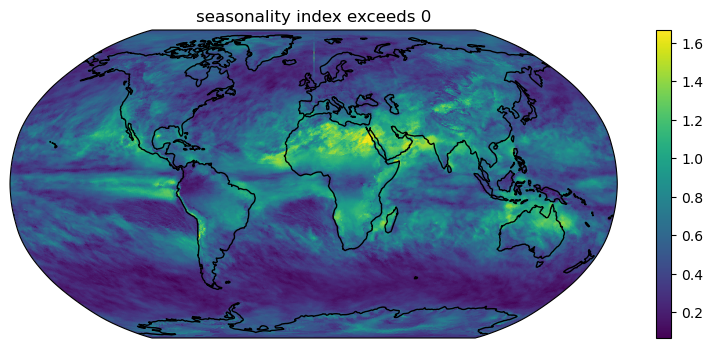

In [7]:

si = seasonality_index(pp)
fig, ax = plt.subplots(figsize=(10, 4), subplot_kw={"projection": ccrs.Robinson()})
ax.set_global()
ax.coastlines()
im = egh.healpix_show(si.where(si > si_thrs), ax=ax)
plt.colorbar(im)
plt.title(f"seasonality index exceeds {si_thrs}")

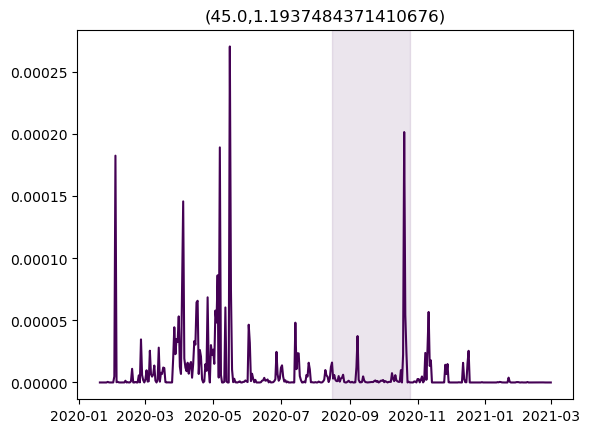

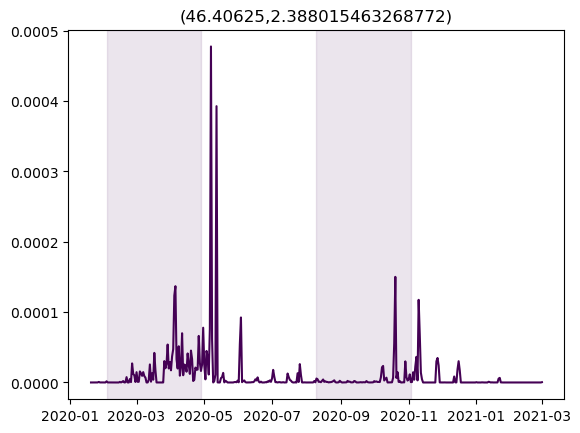

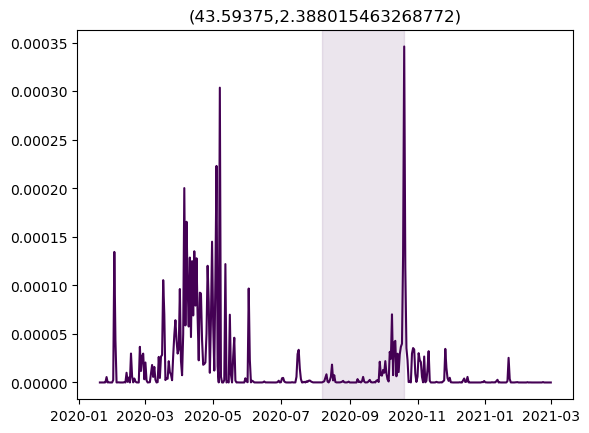

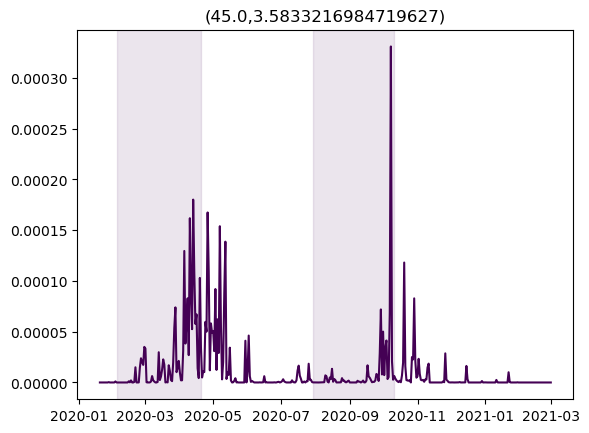

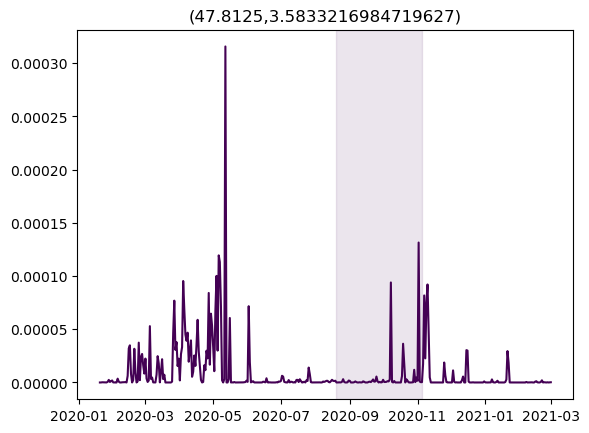

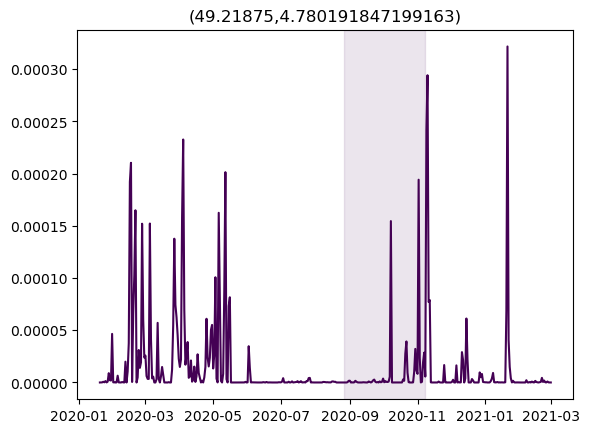

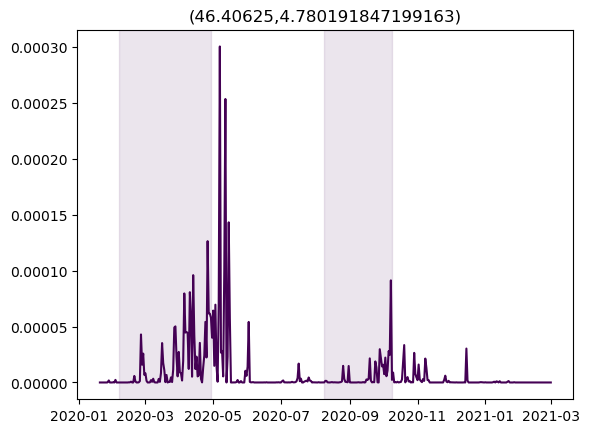

In [61]:
for cell_ix in range(len(ds.pr.cell[::2000])):
    # cell_ix=493
    plt.figure()
    color=plt.cm.viridis(cell_ix/len(ds.pr.cell))
    pp = ds.pr.isel(cell=cell_ix).resample(time="1D").mean()
    fds, lds = onset_period_1d(pp,pp.time,refine=False)

    plt.plot(pp.time, pp, color=color)
    [
        plt.axvspan(
            dt.datetime(2020,1,1)+dt.timedelta(days=int(fds[ix])-1),
            dt.datetime(2020,1,1)+dt.timedelta(days=int(lds[ix])-1),
            alpha=0.1,
            color=color,
        ) 
        for ix in range(len(fds)) if int(fds[ix]==fds[ix])
    ]
    plt.title(f"({pp.lon.data},{pp.lat.data})")

NameError: name 'si' is not defined

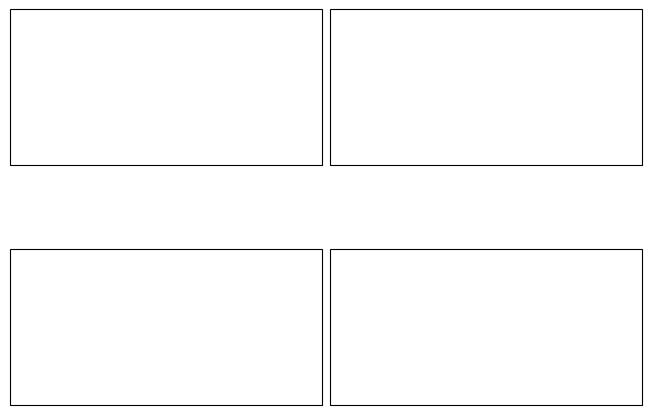

In [4]:
sim = "um_glm_n1280_GAL9_v2_hk26"
# sim = "um_glm_n2560_RAL3p3_tuned_hk26"
max_periods = 2
outdir="onset_dates/"
# zooms = [3, 4, 5, 6]
zooms = [5,6]
# zooms = [3,]
labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)", "(j)", "(k)"]
projection = ccrs.PlateCarree()

for sim in ["um_glm_n1280_GAL9_v2_hk26", "um_glm_n2560_RAL3p3_tuned_hk26"]:
    sim_cat = cat[sim]
    fig, axes = plt.subplots(
        len(zooms),
        2,
        # height_ratios=[1] * len(zooms) + [0.1],
        # figsize=(6, 10),
        subplot_kw={"projection": projection},
        layout="constrained",
    )
    label_ix = 0
    for zoom_ix, zoom in enumerate(zooms):
        ds = sim_cat(zoom=zoom, time="PT1H").to_dask().pipe(hp_mods)
        pp_all = ds.pr.resample(time="1D").mean().chunk(dict(time=-1))
        first_days, last_days = xr.apply_ufunc(
            onset_period_1d,
            pp_all,
            pp_all["time"],
            input_core_dims=[["time"], ["time"]],
            output_core_dims=[["period"], ["period"]],
            kwargs={
                "max_periods": max_periods,
                "max_dry_frac_rainfall": 0.1,
                "refine": False,
                "precip_threshold": None,
                "intensity_threshold": None,
            },
            vectorize=True,
            dask="parallelized",
            output_dtypes=[float, float],
            dask_gufunc_kwargs={
                "output_sizes": {"period": max_periods},
            },
        )

        first_days = first_days.assign_coords(period=np.arange(max_periods)).where(
            si > si_thrs
        )
        last_days = last_days.assign_coords(period=np.arange(max_periods)).where(
            si > si_thrs
        )

        for ix in range(max_periods):
            label = labels[label_ix]
            ax = axes[zoom_ix, ix]
            ax.set_global()
            ax.coastlines()
            im = egh.healpix_show(
                first_days.sel(period=ix) % 365,
                ax=ax,
                vmin=0,
                vmax=365,
                cmap=cmo.cm.phase,
            )

            ax.set_title(f"{label} zoom={zoom}")

            first_days.to_netcdf(f"{outdir}/{sim}_zoom_{zoom}_first_days.nc")
            last_days.to_netcdf(f"{outdir}/{sim}_zoom_{zoom}_last_days.nc")
            label_ix += 1

    fig.suptitle(sim)
    fig.colorbar(
        im,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.07,
        shrink=0.7,
        label="day of year",
    )

In [ ]:
#kscale/USERS/cscullio/DYAMOND3/data_reruns/data_processed/n2560_RAL3p3_tuned/glm/apvere_regridded/glm.n2560_RAL3p3_tuned.apvere_20200123T0000Z_regridded.nc

# regridding healpix

In [3]:
# OPTION B: (Recommended) Compute number of lat and lon points equivalent to Healpix zoom level
#          Note option to define lons [0,360] or [-180,180]
#          Either set bounds [lon1, lon2, lat1, lat2] based on input model domain extent, or user-specified

def hp_to_latlon(ds):
    import ast
    from utils import healpix_zoom_to_grid_area_match
    domain_bounds = ast.literal_eval(ds.attrs.get("regional_bounds"))
    lon1 = domain_bounds["lower_left_lon"]
    lon2 = domain_bounds["upper_right_lon"]
    lat1 = domain_bounds["lower_left_lat"]
    lat2 = domain_bounds["upper_right_lat"]
    
    # Call function to compute nlon, nlat based on zoom level
    nlon, nlat = healpix_zoom_to_grid_area_match(zoom) #, lat1, lat2, lon1, lon2)
    lons = np.linspace(lon1, lon2, nlon)
    lats = np.linspace(lat1, lat2, nlat)
    
    # Get healpix_index coord corresponding to lat/lon mesh
    idx = get_nn_lon_lat_index(2**zoom, lons, lats)

    return ds.sel(cell=idx)

/home/users/franmorr/.conda/envs/hk26_env/lib/python3.14/site-packages/xarray/backends/netCDF4_.py:665: UserWarning: endian-ness of dtype and endian kwarg do not match, using endian kwarg
  nc4_var = self.ds.createVariable(**default_args)
/home/users/franmorr/.conda/envs/hk26_env/lib/python3.14/site-packages/xarray/backends/netCDF4_.py:665: UserWarning: endian-ness of dtype and endian kwarg do not match, using endian kwarg
  nc4_var = self.ds.createVariable(**default_args)
/home/users/franmorr/.conda/envs/hk26_env/lib/python3.14/site-packages/xarray/backends/netCDF4_.py:665: UserWarning: endian-ness of dtype and endian kwarg do not match, using endian kwarg
  nc4_var = self.ds.createVariable(**default_args)
/home/users/franmorr/.conda/envs/hk26_env/lib/python3.14/site-packages/xarray/backends/netCDF4_.py:665: UserWarning: endian-ness of dtype and endian kwarg do not match, using endian kwarg
  nc4_var = self.ds.createVariable(**default_args)
/home/users/franmorr/.conda/envs/hk26_env/li

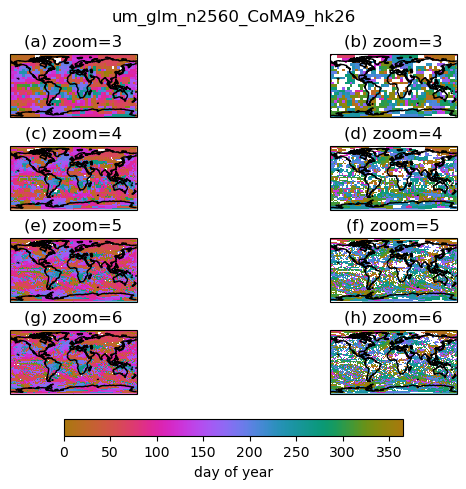

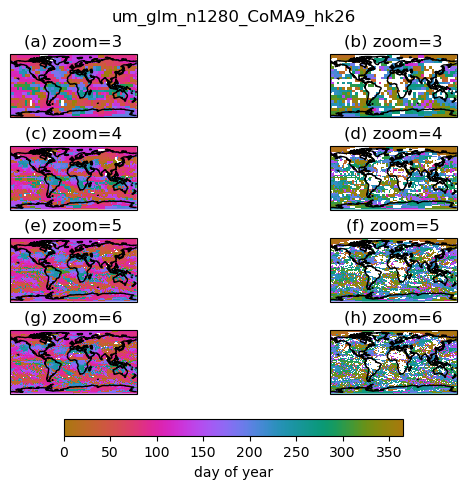

In [7]:
import datetime as dt
import os
import sys

import cartopy.crs as ccrs
import cmocean as cmo
import easygems.healpix as egh
import healpy as hp
import intake
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
# Filter out annoying warning.
import warnings

from utils import get_nn_lon_lat_index, haversine, hp_mods,hp_to_latlon

warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

import OnsetPeriod_toolbox as optb
from onset_utils import onset_period, onset_period_1d, seasonality_index

max_periods = 2
outdir = "onset_dates/"
zooms = [3, 4, 5, 6]
# zooms = [7, 8]
# zooms = [3,4]
labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)", "(i)", "(j)", "(k)"]
projection = ccrs.PlateCarree()

# Open catalog.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']


for sim in ["um_glm_n2560_CoMA9_hk26", "um_glm_n1280_CoMA9_hk26"]:
    sim_cat = cat[sim]
    fig, axes = plt.subplots(
        len(zooms),
        2,
        # height_ratios=[1] * len(zooms) + [0.1],
        # figsize=(6, 10),
        subplot_kw={"projection": projection},
        layout="constrained",
    )
    label_ix = 0
    for zoom_ix, zoom in enumerate(zooms):
        ds = sim_cat(zoom=zoom, time="PT1H").to_dask().pipe(hp_mods)
        ds_latlon = hp_to_latlon(ds,zoom=zoom)
        pp_latlon = ds_latlon.pr.resample(time="1D").mean().chunk(dict(time=-1))
        first_days, last_days = xr.apply_ufunc(
            onset_period_1d,
            pp_latlon,
            pp_latlon["time"],
            input_core_dims=[["time"], ["time"]],
            output_core_dims=[["period"], ["period"]],
            kwargs={
                "max_periods": max_periods,
                "max_dry_frac_rainfall": 0.1,
                "refine": False,
                "precip_threshold": None,
                "intensity_threshold": None,
            },
            vectorize=True,
            dask="parallelized",
            output_dtypes=[float, float],
            dask_gufunc_kwargs={
                "output_sizes": {"period": max_periods},
            },
        )

        first_days = first_days.assign_coords(period=np.arange(max_periods))
        last_days = last_days.assign_coords(period=np.arange(max_periods))

        for ix in range(max_periods):
            label = labels[label_ix]
            ax = axes[zoom_ix, ix]
            ax.set_global()
            ax.coastlines()
            m = (first_days.sel(period=ix) % 365).plot(
                ax=ax, vmin=0, vmax=365, cmap=cmo.cm.phase, add_colorbar=False
            )

            ax.set_title(f"{label} zoom={zoom}")

            first_days.to_netcdf(f"{outdir}/{sim}_zoom_{zoom}_first_days.nc")
            last_days.to_netcdf(f"{outdir}/{sim}_zoom_{zoom}_last_days.nc")
            label_ix += 1

    fig.suptitle(sim)
    fig.colorbar(
        m,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.07,
        shrink=0.7,
        label="day of year",
    )

<xarray.DataArray 'pr' (latitude: 25, longitude: 49, period: 2)> Size: 20kB
dask.array<transpose, shape=(25, 49, 2), dtype=float64, chunksize=(15, 49, 2), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 200B -90.0 -82.5 -75.0 ... 75.0 82.5 90.0
  * longitude  (longitude) float64 392B 0.0 7.5 15.0 22.5 ... 345.0 352.5 360.0
    cell       (latitude, longitude) int64 10kB dask.array<chunksize=(25, 49), meta=np.ndarray>
    lat        (latitude, longitude) float64 10kB dask.array<chunksize=(25, 49), meta=np.ndarray>
    lon        (latitude, longitude) float64 10kB dask.array<chunksize=(25, 49), meta=np.ndarray>
  * period     (period) int64 16B 0 1
    crs        int64 8B 0
Attributes:
    standard_name:  precipitation_flux
    units:          kg m-2 s-1
    source:         Data from Met Office Unified Model
    um_version:     13.5
    STASH:          [1, 5, 205]
    cell_methods:   time: mean (interval: 1 hour)
    long_name:      precipitation_flux
    variable_id:    pr
    UM_vars:        ['convective_rainfall_flux', 'convective_snowfall_flux', ...
    notes:          Combined rain and snow, convective and stratiform. Hourly...
    grid_mapping:   crs